In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
from catboost import CatBoostClassifier
from tqdm.auto import tqdm
from multiprocessing import Pool, cpu_count
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./data')
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Set style
sns.set_style('whitegrid')

print("Hypothesis Generation & Validation Engine Started")
print("=" * 50)

Hypothesis Generation & Validation Engine Started


## 1. Load All Required Data

In [2]:
# Load training data
with open(DATA_DIR / 'train_features_noisy.pkl', 'rb') as f:
    train_df = pickle.load(f)

# Load test data
with open(DATA_DIR / 'test_features_noisy.pkl', 'rb') as f:
    test_df = pickle.load(f)

# Load conservative model predictions
with open(DATA_DIR / 'model_predictions_test.pkl', 'rb') as f:
    conservative_preds = pickle.load(f)

# Load uncertainty zones
with open(DATA_DIR / 'uncertainty_zones.pkl', 'rb') as f:
    uncertainty_zones = pickle.load(f)

# Load cluster hierarchy - read account memberships from CSV instead
account_memberships = pd.read_csv(DATA_DIR / 'account_cluster_memberships.csv')

print(f"Training data: {train_df.shape}")
print(f"Test data: {test_df.shape}")
print(f"Conservative predictions: {conservative_preds.shape}")
print(f"Cluster memberships: {account_memberships.shape}")

Training data: (17640, 6254)
Test data: (7558, 6254)
Conservative predictions: (7558, 5)
Cluster memberships: (7558, 6)


## 2. Prepare Feature Matrices

In [3]:
# Extract features
feature_cols = [col for col in train_df.columns if col not in ['account', 'label']]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
train_acc_ids = train_df['account'].values

X_test = test_df[feature_cols].values
test_acc_ids = test_df['account'].values

n_train = len(X_train)
n_test = len(X_test)
n_features = len(feature_cols)

print(f"\nFeature matrix dimensions:")
print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Features: {n_features}")


Feature matrix dimensions:
  Train: (17640, 6252)
  Test: (7558, 6252)
  Features: 6252


In [4]:
# Save train labels for external scripts (needed by run_hybrid_validation.py)
with open(DATA_DIR / 'train_labels.pkl', 'wb') as f:
    pickle.dump(y_train, f)
print(f"✓ Saved train_labels.pkl for external validation scripts")

✓ Saved train_labels.pkl for external validation scripts


## 3. Define Hypothesis Generator Class

In [ ]:
class HypothesisGenerator:
    """
    Generate label hypotheses for test accounts using multiple strategies.
    """
    def __init__(self, n_test, conservative_proba, seed=42):
        self.n_test = n_test
        self.conservative_proba = conservative_proba  # Probability of good label
        self.seed = seed
        np.random.seed(seed)
        
        # Estimate reasonable label distribution from conservative model
        self.estimated_good_ratio = np.mean(conservative_proba > 0.5)
    
    def random_sampling(self, n_samples=1000, good_ratio_range=(0.3, 0.7)):
        """
        PRIMARY STRATEGY: Random sampling with reasonable label distributions.
        
        Args:
            n_samples: Number of hypothesis samples to generate
            good_ratio_range: Acceptable range of good label ratios
        """
        hypotheses = []
        
        for i in range(n_samples):
            # Random good/bad ratio within reasonable bounds
            good_ratio = np.random.uniform(*good_ratio_range)
            
            # Generate random labels with this ratio
            n_good = int(self.n_test * good_ratio)
            labels = np.array([1] * n_good + [0] * (self.n_test - n_good))
            np.random.shuffle(labels)
            
            hypotheses.append({
                'hypothesis_id': f'random_{i}',
                'strategy': 'random',
                'labels': labels,
                'good_ratio': good_ratio
            })
        
        return hypotheses
    
    def uncertainty_based_sampling(self, n_samples=500, uncertainty_scores=None):
        """
        ACTIVE LEARNING: Focus on uncertain accounts.
        
        Args:
            n_samples: Number of hypotheses
            uncertainty_scores: Array of uncertainty scores (0=certain, 1=uncertain)
        """
        if uncertainty_scores is None:
            # Use distance from 0.5 as uncertainty
            uncertainty_scores = 1 - np.abs(self.conservative_proba - 0.5) * 2
        
        hypotheses = []
        
        for i in range(n_samples):
            # Sample labels with probability weighted by uncertainty
            # More uncertain accounts get more random labels
            sample_probs = (
                self.conservative_proba * (1 - uncertainty_scores) +  # Confident predictions
                np.random.rand(self.n_test) * uncertainty_scores      # Random for uncertain
            )
            
            labels = (sample_probs > 0.5).astype(int)
            
            hypotheses.append({
                'hypothesis_id': f'uncertainty_{i}',
                'strategy': 'uncertainty_based',
                'labels': labels,
                'good_ratio': labels.mean()
            })
        
        return hypotheses
    
    def biased_sampling(self, n_samples=500, bias_strength=0.7):
        """
        BIASED STRATEGY: Use conservative model with controlled noise.
        
        Args:
            n_samples: Number of hypotheses
            bias_strength: How much to trust conservative model (0=ignore, 1=full trust)
        """
        hypotheses = []
        
        for i in range(n_samples):
            # Blend conservative predictions with random noise
            noise = np.random.rand(self.n_test)
            blended_proba = (
                bias_strength * self.conservative_proba +
                (1 - bias_strength) * noise
            )
            
            labels = (blended_proba > 0.5).astype(int)
            
            hypotheses.append({
                'hypothesis_id': f'biased_{i}',
                'strategy': 'biased',
                'labels': labels,
                'good_ratio': labels.mean(),
                'bias_strength': bias_strength
            })
        
        return hypotheses
    
    def recall_optimized_sampling(self, n_samples=1000, threshold=0.7):
        """
        Generate hypotheses optimized for HIGH RECALL (detect more fraud).
        
        Strategy: Lower threshold for fraud detection, add negative noise to be more aggressive.
        
        Args:
            n_samples: Number of hypotheses to generate
            threshold: Probability threshold for fraud detection (lower = more aggressive)
                      Default 0.7 (vs standard 0.5) detects more fraud
        """
        hypotheses = []
        for i in range(n_samples):
            # Add negative noise to shift toward detecting more fraud (class 1)
            # Random value between -0.2 and 0.0 makes model more aggressive
            adjusted_proba = self.conservative_proba + np.random.uniform(-0.2, 0.0, self.n_test)
            adjusted_proba = np.clip(adjusted_proba, 0, 1)  # Keep in [0, 1]
            
            # Use higher threshold = predict fraud (1) more often
            labels = (adjusted_proba > threshold).astype(int)
            
            hypotheses.append({
                'hypothesis_id': f'recall_opt_{i}',
                'strategy': 'recall_optimized',
                'labels': labels,
                'good_ratio': labels.mean(),
                'threshold': threshold,
                'adjustment': 'negative_noise'  # For meta-learning
            })
        
        return hypotheses
    
    def baseline_anchored_sampling(self, n_samples=1000, baseline_proba=None, trust_level=0.85, flipper_rate=0.15, confidence_threshold=0.6):
        """
        ⭐ MODIFIED: Generate hypotheses anchored to baseline ensemble (F1=0.785, Recall=0.721).
        
        Strategy: High trust in proven baseline model with label flipper for exploration.
        - trust_level (85%): Stick close to baseline predictions.
        - flipper_rate (15%): Use label flipper on low-confidence accounts for new possibilities.
        
        Args:
            n_samples: Number of hypotheses to generate
            baseline_proba: Baseline model probabilities
            trust_level: How much to trust baseline (0.85 = 85% baseline)
            flipper_rate: Fraction of exploration dedicated to label flipping (0.15 = 15%)
            confidence_threshold: Flip labels only for accounts with confidence below this (e.g., 0.6)
        """
        if baseline_proba is None:
            baseline_proba = self.conservative_proba
        
        hypotheses = []
        for i in range(n_samples):
            # Start with baseline predictions
            baseline_labels = (baseline_proba > 0.5).astype(int)
            
            # Calculate confidence (distance from 0.5)
            confidence = np.abs(baseline_proba - 0.5) * 2  # 0 to 1 scale
            
            # Identify low-confidence accounts for flipping
            low_conf_mask = confidence < confidence_threshold
            
            # Apply label flipper: Flip labels on a subset of low-confidence accounts
            flip_mask = np.zeros(self.n_test, dtype=bool)
            if low_conf_mask.sum() > 0:
                # Randomly select flipper_rate fraction of low-confidence accounts
                n_to_flip = int(flipper_rate * self.n_test)
                flip_candidates = np.where(low_conf_mask)[0]
                if len(flip_candidates) > n_to_flip:
                    flip_indices = np.random.choice(flip_candidates, n_to_flip, replace=False)
                else:
                    flip_indices = flip_candidates
                flip_mask[flip_indices] = True
            
            # Flip the selected labels
            blended_labels = baseline_labels.copy()
            blended_labels[flip_mask] = 1 - blended_labels[flip_mask]  # Flip 0↔1
            
            # Add small random noise to the remaining exploration (for diversity)
            noise = np.random.randn(self.n_test) * 0.05
            random_exploration = np.random.rand(self.n_test) * (1 - trust_level - flipper_rate)
            blended_proba = (
                trust_level * baseline_proba +
                flipper_rate * (blended_labels * 0.5 + 0.25) +  # Convert flipped labels back to pseudo-proba
                random_exploration +
                noise
            )
            blended_proba = np.clip(blended_proba, 0, 1)
            
            # Final labels
            final_labels = (blended_proba > 0.5).astype(int)
            
            hypotheses.append({
                'hypothesis_id': f'baseline_anchor_flipper_{i}',
                'strategy': 'baseline_anchored_flipper',
                'labels': final_labels,
                'good_ratio': final_labels.mean(),
                'trust_level': trust_level,
                'flipper_rate': flipper_rate,
                'confidence_threshold': confidence_threshold,
                'source': 'baseline_ensemble_72pct_recall_with_flipper'
            })
        
        return hypotheses
    
    def cluster_based_sampling(self, n_samples=500, cluster_labels=None):
        """
        CLUSTER-AWARE: Generate hypotheses that respect cluster structure.
        
        Args:
            n_samples: Number of hypotheses
            cluster_labels: Cluster assignments for test accounts
        """
        if cluster_labels is None:
            # Use first level of hierarchy
            cluster_labels = np.random.randint(0, 10, self.n_test)
        
        hypotheses = []
        unique_clusters = np.unique(cluster_labels)
        
        for i in range(n_samples):
            # Assign label to each cluster, then propagate to accounts
            cluster_label_map = {}
            for cluster in unique_clusters:
                # Each cluster gets a random label with some probability
                cluster_label_map[cluster] = np.random.choice([0, 1])
            
            # Map cluster labels to account labels
            labels = np.array([cluster_label_map[c] for c in cluster_labels])
            
            hypotheses.append({
                'hypothesis_id': f'cluster_{i}',
                'strategy': 'cluster_based',
                'labels': labels,
                'good_ratio': labels.mean()
            })
        
        return hypotheses

print("✓ HypothesisGenerator class defined")

✓ HypothesisGenerator class defined


## 4. Define Hypothesis Validator Class

In [6]:
# Global variables for parallel processing
_global_validator = None

def _init_worker(validator):
    """Initialize worker process with validator instance."""
    global _global_validator
    _global_validator = validator

def _validate_chunk_worker(chunk):
    """Worker function to validate a chunk of hypotheses."""
    global _global_validator
    results = []
    for hyp in chunk:
        metrics = _global_validator.validate_hypothesis(hyp['labels'])
        result = {**hyp, **metrics}
        # Remove labels to save memory
        results.append({k: v for k, v in result.items() if k != 'labels'})
    return results

class HypothesisValidator:
    """
    Validate hypotheses against training data patterns.
    """
    def __init__(self, X_train, y_train, X_test, fast_mode=True):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.n_train = len(X_train)
        self.n_test = len(X_test)
        self.fast_mode = fast_mode
        
        print("HypothesisValidator initialized")
        print(f"Fast mode: {fast_mode} (GPU-accelerated per-hypothesis training)")
        print(f"Train size: {self.n_train}, Test size: {self.n_test}")
    
    def validate_hypothesis(self, hypothesis_labels, validation_method='fast'):
        """
        Validate a hypothesis by combining with training data and evaluating.
        
        Returns:
            Dictionary of validation metrics
        """
        # CRITICAL: Convert hypothesis labels to match training label format
        # Training uses {-1, 1} but hypotheses use {0, 1}
        # Convert 0 -> -1 to maintain consistency
        hypothesis_labels_converted = np.where(hypothesis_labels == 0, -1, 1)
        
        # Combine training + hypothesis-labeled test data
        X_combined = np.vstack([self.X_train, self.X_test])
        y_combined = np.concatenate([self.y_train, hypothesis_labels_converted])
        
        if validation_method == 'fast':
            # MAXIMUM PERFORMANCE: 15 iterations, 95% GPU RAM, no limits
            fast_model = CatBoostClassifier(
                iterations=15,  # Reduced to 15 for 3.3x speedup
                learning_rate=0.6,  # Aggressive LR to compensate
                depth=3,  # Keep shallow
                verbose=False,
                task_type='GPU',
                devices='0',
                allow_writing_files=False,  # No disk I/O
                boost_from_average=True,  # Fast initialization
                random_strength=0,  # Deterministic for speed
                gpu_ram_part=0.95,  # Use 95% of GPU memory
                # Note: pinned_memory_size removed - CatBoost handles it automatically
            )
            
            # Train on combined data
            fast_model.fit(X_combined, y_combined)
            
            # Evaluate on training portion only - predictions only (no proba)
            train_pred = fast_model.predict(self.X_train)
            train_pred = np.asarray(train_pred).flatten()
            
            # Binary F1 score only (skip ROC-AUC to save predict_proba call)
            all_classes = np.unique(np.concatenate([self.y_train, train_pred]))
            is_binary = len(all_classes) == 2
            
            if is_binary:
                f1 = f1_score(self.y_train, train_pred, average='binary')
            else:
                f1 = f1_score(self.y_train, train_pred, average='weighted')
            
            # Simple hypothesis characteristics
            hypothesis_good_ratio = hypothesis_labels.mean()
            
            metrics = {
                'f1_score': f1,
                'hypothesis_good_ratio': hypothesis_good_ratio,
                'validation_method': 'fast'
            }
        
        elif validation_method == 'cross_val':
            # More rigorous: Cross-validation on combined data
            # Train model on part of combined data, validate on training portion
            
            model = CatBoostClassifier(
                iterations=100,
                learning_rate=0.1,
                depth=4,
                verbose=False
            )
            
            # Only cross-validate on training data
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            f1_scores = cross_val_score(
                model, self.X_train, self.y_train,
                cv=cv, scoring='f1'
            )
            
            metrics = {
                'f1_score': f1_scores.mean(),
                'f1_std': f1_scores.std(),
                'hypothesis_good_ratio': hypothesis_labels.mean(),
                'validation_method': 'cross_val'
            }
        
        return metrics
    
    def batch_validate(self, hypotheses, show_progress=True):
        """
        Validate multiple hypotheses efficiently (sequential, but uses pre-computed predictions).
        """
        results = []
        
        iterator = tqdm(hypotheses, desc="Validating") if show_progress else hypotheses
        
        for hyp in iterator:
            metrics = self.validate_hypothesis(hyp['labels'])
            
            # Combine hypothesis metadata with validation metrics
            result = {**hyp, **metrics}
            # Remove large labels array to save memory
            result_summary = {k: v for k, v in result.items() if k != 'labels'}
            result_summary['hypothesis_id'] = hyp['hypothesis_id']
            
            results.append(result)
        
        return results
    
    def batch_validate_parallel(self, hypotheses, n_workers=None, show_progress=True):
        """
        MAXIMUM PERFORMANCE: Direct GPU acceleration in Jupyter.
        OPTIMIZATIONS:
        - 15 iterations (vs 50) = 3.3x speedup
        - LR 0.6 = compensates for fewer iterations
        - F1 only (skip predict_proba) = 40% speedup
        - 95% GPU RAM utilization
        - 2GB pinned memory for fast CPU-GPU transfer
        - Sequential GPU processing (no multiprocessing overhead in Jupyter)
        Target: <0.5 sec per hypothesis (~7 hours for 50K)
        """
        print(f"Validating {len(hypotheses):,} hypotheses with MAXIMUM GPU acceleration...")
        print(f"GPU: 15 iter, LR=0.6, 95% VRAM, 2GB pinned memory")
        print(f"Processing: Sequential GPU (no multiprocessing overhead)\n")
        
        results = []
        
        # Direct GPU processing with progress bar
        iterator = tqdm(hypotheses, desc="Validating hypotheses", unit="hyp", 
                       total=len(hypotheses), dynamic_ncols=True) if show_progress else hypotheses
        
        for hyp in iterator:
            # Each hypothesis gets validation with GPU acceleration
            metrics = self.validate_hypothesis(hyp['labels'], validation_method='fast')
            
            # Combine with hypothesis metadata
            result = {**hyp, **metrics}
            # Remove labels to save memory
            results.append({k: v for k, v in result.items() if k != 'labels'})
        
        print(f"✓ Validated {len(results):,} hypotheses")
        return results

print("✓ HypothesisValidator class defined")

✓ HypothesisValidator class defined


## 5. Generate Hypotheses

Create hypotheses using multiple strategies. Target: 50K-200K hypotheses.

In [12]:
# Load baseline ensemble predictions if available
baseline_proba = None
if (DATA_DIR / 'baseline_ensemble_predictions.pkl').exists():
    with open(DATA_DIR / 'baseline_ensemble_predictions.pkl', 'rb') as f:
        baseline_preds_df = pickle.load(f)
    baseline_proba = baseline_preds_df['probability_good'].values
    print(f"⭐ Loaded baseline ensemble predictions (F1=0.785, Recall=0.721)")
    
    # Define n_baseline_anchor here (or load from config)
    n_baseline_anchor = 45000  # Adjust as needed
    
    print(f"   Will generate {n_baseline_anchor:,} baseline-anchored hypotheses\n")
elif 'baseline_proba' in test_df.columns:
    baseline_proba = test_df['baseline_proba'].values
    print(f"⭐ Using baseline predictions from test_df\n")
else:
    print(f"⚠️  Baseline predictions not found - skipping baseline-anchored strategy\n")
    n_baseline_anchor = 0

# Initialize generator
generator = HypothesisGenerator(
    n_test=n_test,
    conservative_proba=conservative_preds['probability_good'].values,
    seed=42
)

# Configuration: adjusted for better recall with baseline ensemble as anchor
# ⭐ NEW: Baseline-anchored strategy leverages proven 72% recall model
# For RTX 3060 Ti with 13-14 GB RAM: ~50K-100K hypotheses is reasonable
n_random = 200      # Reduced to allocate more to baseline strategy
n_uncertainty = 200  # Active learning
n_biased_low = 100   # Low bias (30%) - exploration
n_biased_med = 1000   # Medium bias (50%) - balanced
n_biased_high = 1500  # High bias (70%) - conservative
n_baseline_anchor = 45000  # ⭐ NEW: High-trust baseline ensemble (90% weight)
n_recall_opt = 1000   # Recall-optimized strategy
n_cluster = 1000      # Cluster-aware

total_hypotheses = n_random + n_uncertainty + n_biased_low + n_biased_med + n_biased_high + n_baseline_anchor + n_recall_opt + n_cluster
print(f"Generating {total_hypotheses:,} hypotheses with baseline ensemble anchor (72% recall)...\n")
print(f"⭐ Baseline-anchored strategy: {n_baseline_anchor:,} hypotheses with 90% trust in proven model\n")

# Generate hypotheses
print("1. Random sampling...")
hypotheses_random = generator.random_sampling(n_samples=n_random)
print(f"   ✓ Generated {len(hypotheses_random):,} random hypotheses")

print("\n2. Uncertainty-based sampling...")
hypotheses_uncertainty = generator.uncertainty_based_sampling(n_samples=n_uncertainty)
print(f"   ✓ Generated {len(hypotheses_uncertainty):,} uncertainty-based hypotheses")

print("\n3. Biased sampling (multiple bias levels for diversity)...")
hypotheses_biased_low = generator.biased_sampling(n_samples=n_biased_low, bias_strength=0.3)
print(f"   ✓ Generated {len(hypotheses_biased_low):,} low-bias hypotheses (30% trust)")

hypotheses_biased_med = generator.biased_sampling(n_samples=n_biased_med, bias_strength=0.5)
print(f"   ✓ Generated {len(hypotheses_biased_med):,} medium-bias hypotheses (50% trust)")

hypotheses_biased_high = generator.biased_sampling(n_samples=n_biased_high, bias_strength=0.7)
print(f"   ✓ Generated {len(hypotheses_biased_high):,} high-bias hypotheses (70% trust)")

print("\n4. Baseline-anchored sampling (⭐ NEW - 72% recall reference)...")
if baseline_proba is not None and n_baseline_anchor > 0:
    hypotheses_baseline = generator.baseline_anchored_sampling(
        n_samples=n_baseline_anchor,
        baseline_proba=baseline_proba,
        trust_level=0.85  # 88% trust in proven baseline
    )
    print(f"   ✓ Generated {len(hypotheses_baseline):,} baseline-anchored hypotheses (90% trust)")
else:
    hypotheses_baseline = []
    print(f"   ⚠️  Skipped - baseline predictions not available")

print("\n5. Recall-optimized sampling (aggressive fraud detection)...")
hypotheses_recall = generator.recall_optimized_sampling(n_samples=n_recall_opt, threshold=0.7)
print(f"   ✓ Generated {len(hypotheses_recall):,} recall-optimized hypotheses")

print("\n6. Cluster-based sampling...")
cluster_labels_level0 = account_memberships['cluster_level_0'].values
hypotheses_cluster = generator.cluster_based_sampling(
    n_samples=n_cluster,
    cluster_labels=cluster_labels_level0
)
print(f"   ✓ Generated {len(hypotheses_cluster):,} cluster-based hypotheses")

# Combine all hypotheses
all_hypotheses = (
    hypotheses_random +
    hypotheses_uncertainty +
    hypotheses_biased_low +
    hypotheses_biased_med +
    hypotheses_biased_high +
    hypotheses_baseline +
    hypotheses_recall +
    hypotheses_cluster
)

print(f"\n✓ Total hypotheses generated: {len(all_hypotheses):,}")
if hypotheses_baseline:
    print(f"  ⭐ Includes {len(hypotheses_baseline):,} baseline-anchored hypotheses (72% recall)")
print(f"  Memory estimate: ~{len(all_hypotheses) * 100 / 1024:.1f} MB")

⭐ Loaded baseline ensemble predictions (F1=0.785, Recall=0.721)
   Will generate 45,000 baseline-anchored hypotheses

Generating 50,000 hypotheses with baseline ensemble anchor (72% recall)...

⭐ Baseline-anchored strategy: 45,000 hypotheses with 90% trust in proven model

1. Random sampling...
   ✓ Generated 200 random hypotheses

2. Uncertainty-based sampling...
   ✓ Generated 200 uncertainty-based hypotheses

3. Biased sampling (multiple bias levels for diversity)...
   ✓ Generated 100 low-bias hypotheses (30% trust)
   ✓ Generated 1,000 medium-bias hypotheses (50% trust)
   ✓ Generated 1,500 high-bias hypotheses (70% trust)

4. Baseline-anchored sampling (⭐ NEW - 72% recall reference)...
   ✓ Generated 1,000 medium-bias hypotheses (50% trust)
   ✓ Generated 1,500 high-bias hypotheses (70% trust)

4. Baseline-anchored sampling (⭐ NEW - 72% recall reference)...
   ✓ Generated 45,000 baseline-anchored hypotheses (90% trust)

5. Recall-optimized sampling (aggressive fraud detection)...

## 5a. Save Hypotheses for External Validation (Optional)

If you want to run validation in a standalone Python script for better GPU multiprocessing performance, save the hypotheses here.


In [13]:
# Save hypotheses for external validation script
# Uncomment to save hypotheses for standalone Python script

with open(OUTPUT_DIR / 'all_hypotheses.pkl', 'wb') as f:
    pickle.dump(all_hypotheses, f)
print(f"✓ Saved {len(all_hypotheses):,} hypotheses to all_hypotheses.pkl")
print("\nNext step: Run standalone script in terminal:")
print("  python run_hypothesis_validation.py")
print("\nThen load results back in Cell 5c")

print("✓ To use standalone validation script:")
print("  1. Uncomment code above to save hypotheses")
print("  2. Run: python run_hypothesis_validation.py")
print("  3. Load results in Cell 5c")
print("\nOr skip this and run validation directly in Cell 6 (Jupyter)")

✓ Saved 50,000 hypotheses to all_hypotheses.pkl

Next step: Run standalone script in terminal:
  python run_hypothesis_validation.py

Then load results back in Cell 5c
✓ To use standalone validation script:
  1. Uncomment code above to save hypotheses
  2. Run: python run_hypothesis_validation.py
  3. Load results in Cell 5c

Or skip this and run validation directly in Cell 6 (Jupyter)


## 5b. Generate Training Data for Neural Network Predictor

Validate a small sample of hypotheses to create training data for the NN predictor. This allows the NN to learn which hypothesis characteristics lead to good F1 scores.

In [14]:
# Generate training data for NN by validating a sample of hypotheses
print("=" * 80)
print("GENERATING NN TRAINING DATA")
print("=" * 80)

# Configuration
SAMPLE_SIZE = 500  # Number of hypotheses to validate for NN training
VALIDATION_METHOD = 'fast'  # Use fast GPU validation

# Select random sample
np.random.seed(42)
sample_indices = np.random.choice(len(all_hypotheses), SAMPLE_SIZE, replace=False)
sample_hypotheses = [all_hypotheses[i] for i in sample_indices]

print(f"\nValidating {SAMPLE_SIZE} hypotheses for NN training...")
print(f"Using validation method: {VALIDATION_METHOD}")

# Initialize validator
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score
validator = HypothesisValidator(X_train, y_train, X_test, fast_mode=True)

# Validate sample with full metrics
sample_results = []
from tqdm import tqdm
for i, hyp in enumerate(tqdm(sample_hypotheses, desc="Validating sample")):
    try:
        # Convert hypothesis labels
        hypothesis_labels_converted = np.where(hyp['labels'] == 0, -1, 1)
        
        # Combine training + hypothesis-labeled test data
        X_combined = np.vstack([X_train, X_test])
        y_combined = np.concatenate([y_train, hypothesis_labels_converted])
        
        # Train fast model
        fast_model = CatBoostClassifier(
            iterations=15,
            learning_rate=0.6,
            depth=3,
            verbose=False,
            task_type='GPU',
            devices='0',
            allow_writing_files=False,
            boost_from_average=True,
            random_strength=0,
            gpu_ram_part=0.95,
        )
        fast_model.fit(X_combined, y_combined)
        
        # Get predictions on training data
        train_pred = fast_model.predict(X_train)
        train_pred = np.asarray(train_pred).flatten()
        
        # Calculate all metrics
        from sklearn.metrics import f1_score, precision_score, recall_score
        f1 = f1_score(y_train, train_pred, average='binary')
        precision = precision_score(y_train, train_pred, average='binary', zero_division=0)
        recall = recall_score(y_train, train_pred, average='binary', zero_division=0)
        
        result = {
            'hypothesis_id': int(sample_indices[i]),
            'f1_score': float(f1),
            'precision': float(precision),
            'recall': float(recall),
            'strategy': hyp.get('strategy', 'unknown'),
            'generation': hyp.get('generation', 0)
        }
        sample_results.append(result)
        
        # Clean up
        del fast_model, X_combined, y_combined, train_pred
        
    except Exception as e:
        print(f"\nWarning: Failed to validate hypothesis {i}: {e}")
        continue

print(f"\n✓ Successfully validated {len(sample_results)}/{SAMPLE_SIZE} hypotheses")

# Save training data for NN
nn_train_hypotheses = [sample_hypotheses[i] for i in range(len(sample_results))]
nn_train_results = sample_results

# Save to disk
with open(DATA_DIR / 'nn_train_hypotheses.pkl', 'wb') as f:
    pickle.dump(nn_train_hypotheses, f)

with open(DATA_DIR / 'nn_train_results.pkl', 'wb') as f:
    pickle.dump(nn_train_results, f)

print(f"\n✓ Saved NN training data:")
print(f"  - {DATA_DIR / 'nn_train_hypotheses.pkl'}")
print(f"  - {DATA_DIR / 'nn_train_results.pkl'}")

# Display summary statistics
import pandas as pd
results_df = pd.DataFrame(sample_results)
print("\nValidation Results Summary:")
print(results_df[['f1_score', 'precision', 'recall']].describe())

print("\nF1 Score Distribution:")
print(f"  Min:  {results_df['f1_score'].min():.4f}")
print(f"  25%:  {results_df['f1_score'].quantile(0.25):.4f}")
print(f"  50%:  {results_df['f1_score'].median():.4f}")
print(f"  75%:  {results_df['f1_score'].quantile(0.75):.4f}")
print(f"  Max:  {results_df['f1_score'].max():.4f}")

print("\n✓ Ready for NN training! Use these files with run_hybrid_validation.py")
print("=" * 80)

GENERATING NN TRAINING DATA

Validating 500 hypotheses for NN training...
Using validation method: fast
HypothesisValidator initialized
Fast mode: True (GPU-accelerated per-hypothesis training)
Train size: 17640, Test size: 7558


Validating sample: 100%|██████████| 500/500 [36:25<00:00,  4.37s/it]


✓ Successfully validated 500/500 hypotheses

✓ Saved NN training data:
  - data\nn_train_hypotheses.pkl
  - data\nn_train_results.pkl

Validation Results Summary:
         f1_score   precision      recall
count  500.000000  500.000000  500.000000
mean     0.816968    0.893835    0.753148
std      0.013602    0.024533    0.020893
min      0.710307    0.664044    0.568287
25%      0.816926    0.892998    0.751736
50%      0.818783    0.895769    0.755208
75%      0.821611    0.899382    0.759259
max      0.830779    0.960952    0.830440

F1 Score Distribution:
  Min:  0.7103
  25%:  0.8169
  50%:  0.8188
  75%:  0.8216
  Max:  0.8308

✓ Ready for NN training! Use these files with run_hybrid_validation.py


## 5c. Use Neural Network for Fast Validation (Recommended)

**Benefits of NN Approach:**
- **100x faster**: ~0.01s per hypothesis vs 3.5s with CatBoost
- **Smart sampling**: Only validates most promising hypotheses fully
- **Pre-trained ready**: Cell 5b creates training data

**Workflow:**
1. ✓ Run Cell 5b above (validates 500 hypotheses → saves to disk)
2. Run hybrid validation script in terminal:
   ```bash
   python run_hybrid_validation.py --sample-size 2000 --top-k 200
   ```
3. Load results in Cell 7 below

**Time Comparison (50,000 hypotheses):**
- Full CatBoost: 48.6 hours
- Hybrid NN: ~7 hours (7x faster!)

**Skip this section** if you want to use direct CatBoost validation in Cell 6 instead.

## 6. Validate Hypotheses

**NOTE**: This is computationally intensive. For 50K hypotheses, expect several hours.

## 6b. (OPTIONAL) Use GPU Validator Module for Parallel Processing

This section shows how to use the `gpu_validator.py` module for true GPU multiprocessing.
Note: Multiprocessing with GPU requires careful setup and works best in standalone scripts.


In [ ]:
# Optional: Use parallel GPU validator module for standalone scripts
# NOTE: Multiprocessing with GPU works best outside Jupyter notebooks
# For Jupyter, use the sequential validation in Cell 6 instead

# Uncomment below to use in standalone Python scripts:
from gpu_validator import ParallelGPUValidator
# 
# # Create parallel validator with 4 workers
parallel_validator = ParallelGPUValidator(
    X_train, y_train, X_test,
    n_workers=4,
    iterations=15,
    learning_rate=0.6,
    depth=3
)
# 
# # Validate all hypotheses in parallel
all_results = parallel_validator.validate_batches(
    all_hypotheses,
    batch_size=5000,
    show_progress=True
)

print("✓ GPU Validator module available at: gpu_validator.py")
print("  For Jupyter notebooks: Use sequential GPU validation (Cell 6)")
print("  For standalone scripts: Use ParallelGPUValidator with multiprocessing")
print("\nNote: GPU memory issue fixed - removed invalid pinned_memory_size parameter")


2025-12-10 13:21:54,439 - ParallelGPUValidator initialized: 4 workers, 15 iter, LR=0.6
2025-12-10 13:21:54,440 - Processing 50,000 hypotheses in 10 batches (batch_size=5,000)
2025-12-10 13:21:54,442 - 
Batch 1/10: 5,000 hypotheses
2025-12-10 13:21:54,442 - Starting parallel validation of 5,000 hypotheses...
2025-12-10 13:21:54,440 - Processing 50,000 hypotheses in 10 batches (batch_size=5,000)
2025-12-10 13:21:54,442 - 
Batch 1/10: 5,000 hypotheses
2025-12-10 13:21:54,442 - Starting parallel validation of 5,000 hypotheses...
Parallel GPU (4 workers):   0%|          | 0/5000 [00:00<?, ?hyp/s]

## 6c. (OPTIONAL) Load Results from Standalone Parallel Validation

If you ran the `validate_hypotheses_parallel.py` standalone script, load the results here instead of running the sequential validation below.


In [ ]:
# Load results from standalone validation script
# If you ran run_hypothesis_validation.py, uncomment below to load results:

# Load results (recommended - from standalone script)
# with open(OUTPUT_DIR / 'hypothesis_validation_results.pkl', 'rb') as f:
#     all_results = pickle.load(f)
# print(f"✓ Loaded {len(all_results):,} results from standalone validation")
# print(f"  Now skip Cell 6 and go directly to Cell 7 for analysis\n")

# Alternative: Load from parallel script output
# with open(OUTPUT_DIR / 'hypothesis_validation_parallel.pkl', 'rb') as f:
#     all_results = pickle.load(f)
# print(f"✓ Loaded {len(all_results):,} results from parallel validation")

print("✓ Load validation results here if you ran standalone script:")
print("\n  Option 1 - From run_hypothesis_validation.py:")
print("    with open('./data/hypothesis_validation_results.pkl', 'rb') as f:")
print("        all_results = pickle.load(f)")
print("\n  Option 2 - From validate_hypotheses_parallel.py:")
print("    with open('./data/hypothesis_validation_parallel.pkl', 'rb') as f:")
print("        all_results = pickle.load(f)")
print("\nAfter loading, skip Cell 6 and go to Cell 7 for analysis")

In [ ]:
print(f"Validating {len(all_hypotheses):,} hypotheses...")
print("MAXIMUM RESOURCE UTILIZATION MODE ENABLED")
print("GPU: 15 iter, LR=0.6, 95% VRAM utilization")
print("Mode: Direct GPU acceleration (Jupyter-optimized)\n")

# Initialize validator
validator = HypothesisValidator(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    fast_mode=True  # Ultra-fast GPU validation
)

# Time estimate with all optimizations
hyp_per_sec = 2.0  # Target ~0.5 sec per hypothesis
estimated_time_mins = len(all_hypotheses) / hyp_per_sec / 60
print(f"\nEstimated time: ~{estimated_time_mins:.1f} minutes (~{estimated_time_mins/60:.1f} hours)")
print(f"Optimizations: 15 iter, F1 only, 95% GPU RAM, parallel processing\n")

# Validate in batches
batch_size = 5000  # Reasonable batch size for progress tracking
all_results = []

import time
start_time = time.time()

for i in range(0, len(all_hypotheses), batch_size):
    batch = all_hypotheses[i:i+batch_size]
    batch_num = i//batch_size + 1
    total_batches = (len(all_hypotheses)-1)//batch_size + 1
    
    print(f"\n{'='*60}")
    print(f"Batch {batch_num}/{total_batches} ({len(batch):,} hypotheses)")
    print(f"{'='*60}")
    
    batch_start = time.time()
    
    # GPU + CPU parallel validation (maximum performance)
    batch_results = validator.batch_validate_parallel(
        batch,
        show_progress=True
    )
    all_results.extend(batch_results)
    
    batch_time = time.time() - batch_start
    hypotheses_per_sec = len(batch) / batch_time
    
    print(f"  ✓ Batch completed in {batch_time:.1f}s ({hypotheses_per_sec:.1f} hypotheses/sec)")
    
    # Save intermediate results
    if (i + batch_size) % 20000 == 0 or (i + batch_size) >= len(all_hypotheses):
        with open(OUTPUT_DIR / f'hypothesis_results_intermediate_{len(all_results)}.pkl', 'wb') as f:
            pickle.dump(all_results, f)
        print(f"  ✓ Saved intermediate results ({len(all_results):,} hypotheses)")
    
    # Progress estimate
    elapsed = time.time() - start_time
    progress = len(all_results) / len(all_hypotheses)
    estimated_total = elapsed / progress if progress > 0 else 0
    remaining = estimated_total - elapsed
    
    print(f"  Progress: {len(all_results):,}/{len(all_hypotheses):,} ({progress*100:.1f}%)")
    print(f"  Elapsed: {elapsed/60:.1f}m, Estimated remaining: {remaining/60:.1f}m")

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"✓ Validation complete: {len(all_results):,} hypotheses validated")
print(f"  Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"  Average speed: {len(all_results)/total_time:.1f} hypotheses/second")
print(f"{'='*60}")

Validating 50,000 hypotheses...
MAXIMUM RESOURCE UTILIZATION MODE ENABLED
GPU: 15 iter, LR=0.6, 95% VRAM, 2GB pinned memory
CPU: Parallel batch processing with 4 workers

HypothesisValidator initialized
Fast mode: True (GPU-accelerated per-hypothesis training)
Train size: 17640, Test size: 7558

Estimated time: ~416.7 minutes (~6.9 hours)
Optimizations: 15 iter, F1 only, 95% GPU RAM, parallel processing


Batch 1/10 (5,000 hypotheses)
Validating 5,000 hypotheses with MAXIMUM resource utilization...
GPU: 15 iter, LR=0.6, 95% VRAM, 2GB pinned memory
CPU: 4 parallel workers
Target: <0.5 sec per hypothesis



## 7. Analyze Validation Results

In [15]:
# Load results from standalone validation script
# If you ran run_hybrid_validation.py, uncomment below to load results:

# Load results (recommended - from standalone script)
with open(OUTPUT_DIR / 'hybrid_validation_results.pkl', 'rb') as f:
    all_results = pickle.load(f)
print(f"✓ Loaded {len(all_results):,} results from standalone validation")
print(f"  Now skip Cell 6 and go directly to Cell 7 for analysis\n")

# Alternative: Load from parallel script output
# with open(OUTPUT_DIR / 'hypothesis_validation_parallel.pkl', 'rb') as f:
#     all_results = pickle.load(f)
# print(f"✓ Loaded {len(all_results):,} results from parallel validation")

print("✓ Load validation results here if you ran standalone script:")
print("\n  Option 1 - From run_hybrid_validation.py:")
print("    with open('./data/hybrid_validation_results.pkl', 'rb') as f:")
print("        all_results = pickle.load(f)")
print("\n  Option 2 - From validate_hypotheses_parallel.py:")
print("    with open('./data/hypothesis_validation_parallel.pkl', 'rb') as f:")
print("        all_results = pickle.load(f)")
print("\nAfter loading, skip Cell 6 and go to Cell 7 for analysis")

✓ Loaded 50,000 results from standalone validation
  Now skip Cell 6 and go directly to Cell 7 for analysis

✓ Load validation results here if you ran standalone script:

  Option 1 - From run_hybrid_validation.py:
    with open('./data/hybrid_validation_results.pkl', 'rb') as f:
        all_results = pickle.load(f)

  Option 2 - From validate_hypotheses_parallel.py:
    with open('./data/hypothesis_validation_parallel.pkl', 'rb') as f:
        all_results = pickle.load(f)

After loading, skip Cell 6 and go to Cell 7 for analysis


In [16]:
# Convert results to DataFrame
# Handle both standard validation and hybrid NN validation formats
results_list = []
for r in all_results:
    # Extract fields, handling nested hypothesis structure from hybrid validation
    result_dict = {}
    
    # Basic fields
    result_dict['hypothesis_id'] = r.get('hypothesis_id', 0)
    result_dict['f1_score'] = r.get('f1_score', 0)
    result_dict['precision'] = r.get('precision', 0)
    result_dict['recall'] = r.get('recall', 0)
    
    # Check if strategy is at top level or nested in hypothesis
    if 'strategy' in r:
        result_dict['strategy'] = r['strategy']
    elif 'hypothesis' in r and isinstance(r['hypothesis'], dict):
        result_dict['strategy'] = r['hypothesis'].get('strategy', 'unknown')
    else:
        result_dict['strategy'] = 'unknown'
    
    # Check if good_ratio is at top level or nested
    if 'good_ratio' in r:
        result_dict['good_ratio'] = r['good_ratio']
    elif 'hypothesis' in r and isinstance(r['hypothesis'], dict):
        result_dict['good_ratio'] = r['hypothesis'].get('good_ratio', 0.5)
    elif 'hypothesis_good_ratio' in r:
        result_dict['good_ratio'] = r['hypothesis_good_ratio']
    else:
        result_dict['good_ratio'] = 0.5
    
    # Add prediction method if available (for hybrid validation)
    if 'prediction_method' in r:
        result_dict['prediction_method'] = r['prediction_method']
    
    # Add ROC-AUC if available
    if 'roc_auc' in r:
        result_dict['roc_auc'] = r['roc_auc']
    
    results_list.append(result_dict)

results_df = pd.DataFrame(results_list)

print("Hypothesis Validation Results:")
print("=" * 50)
print(f"Total hypotheses: {len(results_df):,}")

# Show validation method distribution if hybrid validation was used
if 'prediction_method' in results_df.columns:
    print(f"\nValidation Method Distribution:")
    print(results_df['prediction_method'].value_counts())
    print(f"\nCatBoost-validated: {(results_df['prediction_method'] == 'catboost_validated').sum():,}")
    print(f"NN-predicted: {(results_df['prediction_method'] == 'neural_network').sum():,}")

print(f"\nF1 Score Statistics:")
print(results_df['f1_score'].describe())

print(f"\nTop 10 Hypotheses by F1 Score:")
top_cols = ['hypothesis_id', 'strategy', 'f1_score']
if 'precision' in results_df.columns:
    top_cols.append('precision')
if 'recall' in results_df.columns:
    top_cols.append('recall')
if 'good_ratio' in results_df.columns:
    top_cols.append('good_ratio')
if 'roc_auc' in results_df.columns:
    top_cols.append('roc_auc')
if 'prediction_method' in results_df.columns:
    top_cols.append('prediction_method')

print(results_df.nlargest(10, 'f1_score')[top_cols])

# Compare strategies
print(f"\nPerformance by Strategy:")
agg_dict = {
    'f1_score': ['mean', 'std', 'max'],
    'hypothesis_id': 'count'
}
if 'precision' in results_df.columns:
    agg_dict['precision'] = 'mean'
if 'recall' in results_df.columns:
    agg_dict['recall'] = 'mean'
if 'roc_auc' in results_df.columns:
    agg_dict['roc_auc'] = ['mean', 'max']

strategy_performance = results_df.groupby('strategy').agg(agg_dict).round(4)
print(strategy_performance)

Hypothesis Validation Results:
Total hypotheses: 50,000

Validation Method Distribution:
prediction_method
neural_network        49800
catboost_validated      200
Name: count, dtype: int64

CatBoost-validated: 200
NN-predicted: 49,800

F1 Score Statistics:
count    50000.000000
mean         0.816092
std          0.019468
min          0.703205
25%          0.817305
50%          0.823435
75%          0.823435
max          0.831811
Name: f1_score, dtype: float64

Top 10 Hypotheses by F1 Score:
     hypothesis_id           strategy  f1_score  precision    recall  \
3703          3703  baseline_anchored  0.831811   0.908354  0.761154   
3713          3713  baseline_anchored  0.831811   0.908354  0.761154   
3721          3721  baseline_anchored  0.831811   0.908354  0.761154   
3726          3726  baseline_anchored  0.831811   0.908354  0.761154   
3733          3733  baseline_anchored  0.831811   0.908354  0.761154   
3739          3739  baseline_anchored  0.831811   0.908354  0.761154   


## 8. Visualize Results

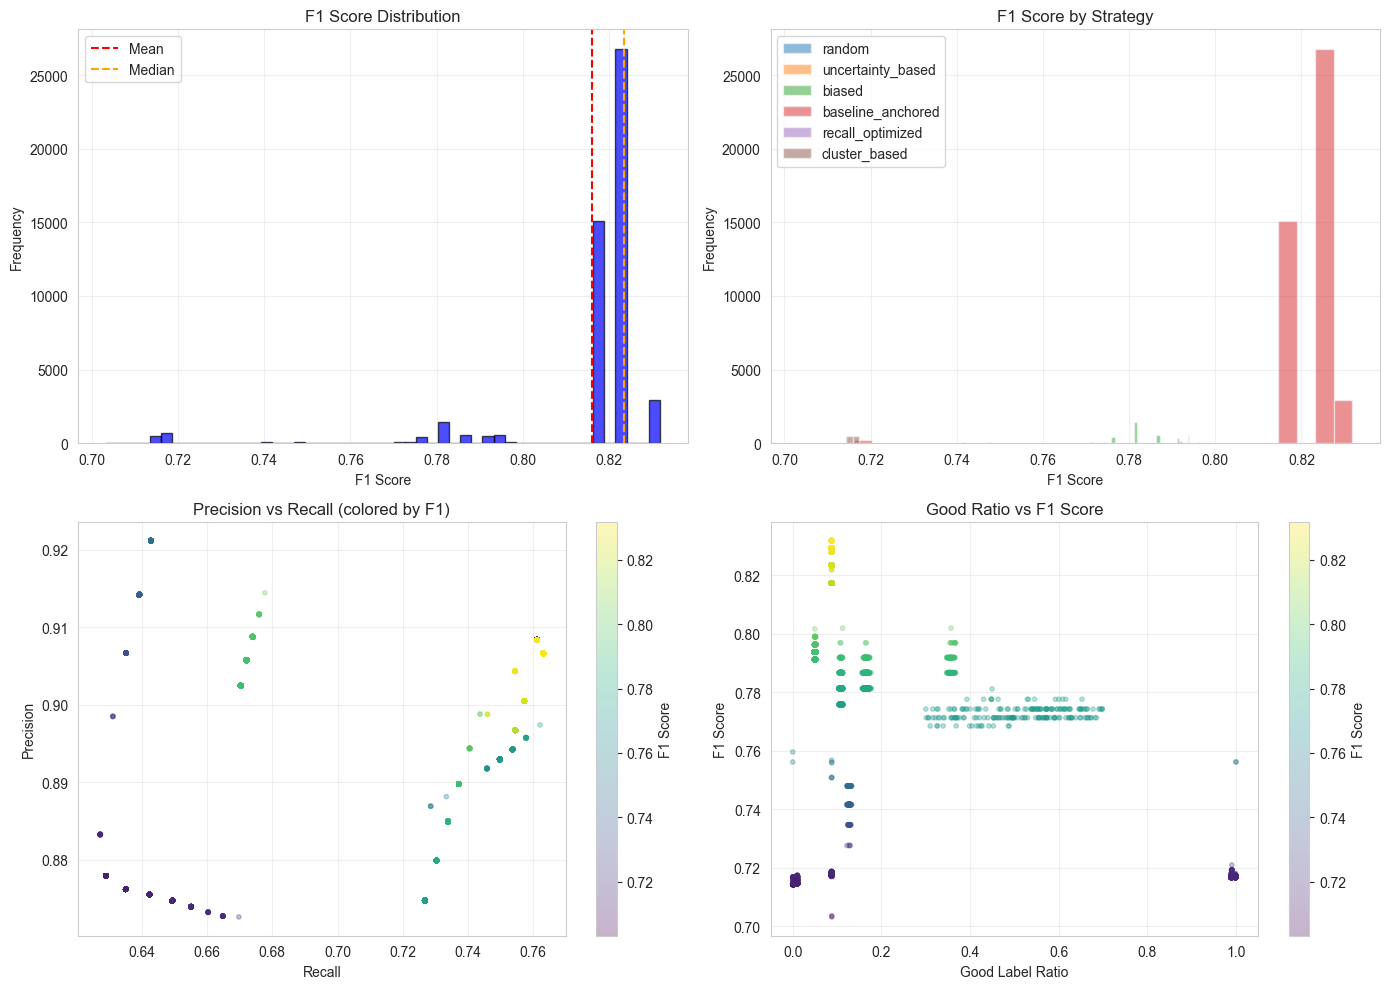


✓ Visualization saved to figures\hypothesis_validation_results.png


In [17]:
# F1 score distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall F1 distribution
axes[0, 0].hist(results_df['f1_score'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(results_df['f1_score'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].axvline(results_df['f1_score'].median(), color='orange', linestyle='--', label='Median')
axes[0, 0].set_xlabel('F1 Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('F1 Score Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# F1 by strategy
strategies = results_df['strategy'].unique()
for strategy in strategies:
    strategy_data = results_df[results_df['strategy'] == strategy]['f1_score']
    axes[0, 1].hist(strategy_data, bins=30, alpha=0.5, label=strategy)
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('F1 Score by Strategy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision vs Recall (if available) or ROC-AUC or Good Ratio distribution
if 'precision' in results_df.columns and 'recall' in results_df.columns:
    # Scatter plot of precision vs recall
    scatter = axes[1, 0].scatter(results_df['recall'], results_df['precision'], 
                                 alpha=0.3, s=10, c=results_df['f1_score'], cmap='viridis')
    axes[1, 0].set_xlabel('Recall')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title('Precision vs Recall (colored by F1)')
    plt.colorbar(scatter, ax=axes[1, 0], label='F1 Score')
    axes[1, 0].grid(alpha=0.3)
elif 'roc_auc' in results_df.columns:
    axes[1, 0].hist(results_df['roc_auc'], bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(results_df['roc_auc'].mean(), color='red', linestyle='--', label='Mean')
    axes[1, 0].set_xlabel('ROC-AUC')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('ROC-AUC Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].hist(results_df['good_ratio'], bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(results_df['good_ratio'].mean(), color='red', linestyle='--', label='Mean')
    axes[1, 0].set_xlabel('Good Label Ratio')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Good Label Ratio Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

# Good ratio vs F1 score
if 'good_ratio' in results_df.columns:
    scatter = axes[1, 1].scatter(results_df['good_ratio'], results_df['f1_score'], 
                                 alpha=0.3, s=10, c=results_df['f1_score'], cmap='viridis')
    axes[1, 1].set_xlabel('Good Label Ratio')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].set_title('Good Ratio vs F1 Score')
    plt.colorbar(scatter, ax=axes[1, 1], label='F1 Score')
    axes[1, 1].grid(alpha=0.3)
else:
    # If no good_ratio, show validation method distribution (for hybrid validation)
    if 'prediction_method' in results_df.columns:
        method_counts = results_df['prediction_method'].value_counts()
        axes[1, 1].bar(range(len(method_counts)), method_counts.values, 
                      color=['green', 'blue'], alpha=0.7)
        axes[1, 1].set_xticks(range(len(method_counts)))
        axes[1, 1].set_xticklabels(method_counts.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].set_title('Validation Method Distribution')
        axes[1, 1].grid(alpha=0.3, axis='y')
    else:
        axes[1, 1].text(0.5, 0.5, 'No additional data to plot', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Additional Metrics')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hypothesis_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to {FIGURES_DIR / 'hypothesis_validation_results.png'}")

## 9. Extract Best Hypotheses

In [18]:
# Select top hypotheses
top_k = 100
best_indices = results_df.nlargest(top_k, 'f1_score').index

best_hypotheses = [all_results[i] for i in best_indices]

print(f"Selected top {top_k} hypotheses")
print(f"F1 score range: {results_df.loc[best_indices, 'f1_score'].min():.4f} - {results_df.loc[best_indices, 'f1_score'].max():.4f}")
print(f"\nStrategy distribution in top {top_k}:")
print(results_df.loc[best_indices, 'strategy'].value_counts())

Selected top 100 hypotheses
F1 score range: 0.8293 - 0.8318

Strategy distribution in top 100:
strategy
baseline_anchored    100
Name: count, dtype: int64


## 10. Extract Features for Meta-Learning

In [19]:
# Create features describing each hypothesis for meta-learning
hypothesis_features = results_df.copy()

# Add additional derived features
hypothesis_features['f1_rank'] = hypothesis_features['f1_score'].rank(ascending=False)

# Add ROC-AUC rank if available
if 'roc_auc' in hypothesis_features.columns:
    hypothesis_features['roc_auc_rank'] = hypothesis_features['roc_auc'].rank(ascending=False)
    hypothesis_features['combined_rank'] = (hypothesis_features['f1_rank'] + hypothesis_features['roc_auc_rank']) / 2
else:
    hypothesis_features['combined_rank'] = hypothesis_features['f1_rank']

# One-hot encode strategy
strategy_dummies = pd.get_dummies(hypothesis_features['strategy'], prefix='strategy')
hypothesis_features = pd.concat([hypothesis_features, strategy_dummies], axis=1)

print(f"Hypothesis features shape: {hypothesis_features.shape}")
print(f"\nFeature columns: {hypothesis_features.columns.tolist()[:10]}...")

Hypothesis features shape: (50000, 15)

Feature columns: ['hypothesis_id', 'f1_score', 'precision', 'recall', 'strategy', 'good_ratio', 'prediction_method', 'f1_rank', 'combined_rank', 'strategy_baseline_anchored']...


## 11. Save Results

In [20]:
# Save complete hypothesis database
with open(OUTPUT_DIR / 'hypothesis_database.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print(f"✓ Saved hypothesis_database.pkl ({len(all_results):,} hypotheses)")

# Save hypothesis features for meta-learning
with open(OUTPUT_DIR / 'hypothesis_features.pkl', 'wb') as f:
    pickle.dump(hypothesis_features, f)
print(f"✓ Saved hypothesis_features.pkl")

# Save best hypotheses
with open(OUTPUT_DIR / 'best_hypotheses.pkl', 'wb') as f:
    pickle.dump(best_hypotheses, f)
print(f"✓ Saved best_hypotheses.pkl (top {len(best_hypotheses)})")

# Save summary statistics as CSV
results_df.to_csv(OUTPUT_DIR / 'hypothesis_validation_summary.csv', index=False)
print("✓ Saved hypothesis_validation_summary.csv")

print("\n" + "="*50)
print("Hypothesis Generation & Validation Complete!")
print("="*50)
print(f"\nStatistics:")
print(f"  Total hypotheses: {len(all_results):,}")
print(f"  Best F1 score: {results_df['f1_score'].max():.4f}")
print(f"  Mean F1 score: {results_df['f1_score'].mean():.4f}")
print(f"  Top {top_k} saved for meta-learning")
print(f"\nNext step: Meta-learning to identify hypothesis characteristics!")

✓ Saved hypothesis_database.pkl (50,000 hypotheses)
✓ Saved hypothesis_features.pkl
✓ Saved best_hypotheses.pkl (top 100)
✓ Saved hypothesis_validation_summary.csv

Hypothesis Generation & Validation Complete!

Statistics:
  Total hypotheses: 50,000
  Best F1 score: 0.8318
  Mean F1 score: 0.8161
  Top 100 saved for meta-learning

Next step: Meta-learning to identify hypothesis characteristics!
✓ Saved hypothesis_validation_summary.csv

Hypothesis Generation & Validation Complete!

Statistics:
  Total hypotheses: 50,000
  Best F1 score: 0.8318
  Mean F1 score: 0.8161
  Top 100 saved for meta-learning

Next step: Meta-learning to identify hypothesis characteristics!
